# Load model checkpoint and evaluate performance

In [41]:
import torch
import sys
sys.path.append("../")
sys.path.append("../src")
sys.path.append("../src/models")
sys.path.append("../src/data")
sys.path.append("../src/utils")
sys.path.append("../src/data/components/")
sys.path.append("../src/models/components/")
sys.path.append("../src/utils/IEBCS")
sys.path.append("../src/utils/IEBCS/representations")
import eventIO, event_representations
from topspin_datamodule import TopspinDataModule, pad_collate_fn
from topspin_classification_module import TopspinLitModule
from TOPSPIN import Hdf5Dataset
from tqdm import tqdm
import numpy as np

# Load checkpoint

In [28]:
checpoint_path = "../logs/train/runs/" + "2025-08-20_18-03-34/" + "checkpoints/" + "epoch_035.ckpt"

# model = torch.load(checpoint_path, map_location=torch.device('cpu'), weights_only=False)
model = TopspinLitModule.load_from_checkpoint(checpoint_path)

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [29]:
data_module = TopspinDataModule(
    data_dir="/data/lkolmar/datasets/topspin_fit_to_max/",
    time_window=5000,  # in us
    num_bins=10,
    sensor_size=(100, 100),
    train_val_test_split=(1294, 277, 277),  # n = 1848 (70%, 15%, 15%)
    batch_size=8,
    num_workers=4,
    pin_memory=True,
)
data_module.prepare_data()
data_module.setup()
test_loader = data_module.test_dataloader()

[229, 1637, 1827, 315, 1373, 1100, 810, 160, 1573, 864, 1516, 837, 586, 341, 361, 527, 881, 1125, 158, 1677, 874, 1245, 1301, 503, 1508, 995, 99, 19, 278, 76, 851, 919, 342, 1383, 127, 1759, 927, 88, 1834, 1498, 556, 129, 462, 1585, 1078, 911, 293, 114, 1267, 943, 214, 526, 1595, 196, 5, 330, 299, 716, 679, 331, 1711, 733, 372, 126, 1461, 703, 77, 474, 1415, 647, 1471, 1786, 45, 494, 153, 1094, 696, 30, 1172, 833, 1625, 725, 1111, 1420, 1375, 657, 1056, 879, 452, 961, 547, 1281, 1543, 1241, 1806, 230, 403, 173, 1254, 1787, 1028, 681, 117, 304, 1636, 1050, 314, 869, 1752, 699, 710, 1258, 1164, 258, 896, 1190, 1351, 287, 797, 1432, 1746, 1230, 1080, 496, 1644, 1613, 1413, 9, 379, 780, 1463, 1754, 410, 565, 337, 1322, 356, 1359, 206, 40, 236, 1087, 1483, 1137, 905, 928, 1119, 1833, 20, 1314, 1043, 1047, 621, 1280, 708, 845, 1591, 415, 1841, 618, 1386, 268, 1151, 251, 913, 14, 652, 409, 885, 1112, 1157, 844, 1737, 1757, 557, 327, 429, 1428, 1382, 324, 328, 920, 693, 1072, 904, 1820, 581, 4

In [42]:
test_dataset = Hdf5Dataset(
    dataset_path="/data/lkolmar/datasets/topspin_fit_to_max/",
    indices=[229, 1637, 1827, 315, 1373, 1100, 810, 160, 1573, 864, 1516, 837, 586, 341, 361, 527, 881, 1125, 158, 1677, 874, 1245, 1301, 503, 1508, 995, 99, 19, 278, 76, 851, 919, 342, 1383, 127, 1759, 927, 88, 1834, 1498, 556, 129, 462, 1585, 1078, 911, 293, 114, 1267, 943, 214, 526, 1595, 196, 5, 330, 299, 716, 679, 331, 1711, 733, 372, 126, 1461, 703, 77, 474, 1415, 647, 1471, 1786, 45, 494, 153, 1094, 696, 30, 1172, 833, 1625, 725, 1111, 1420, 1375, 657, 1056, 879, 452, 961, 547, 1281, 1543, 1241, 1806, 230, 403, 173, 1254, 1787, 1028, 681, 117, 304, 1636, 1050, 314, 869, 1752, 699, 710, 1258, 1164, 258, 896, 1190, 1351, 287, 797, 1432, 1746, 1230, 1080, 496, 1644, 1613, 1413, 9, 379, 780, 1463, 1754, 410, 565, 337, 1322, 356, 1359, 206, 40, 236, 1087, 1483, 1137, 905, 928, 1119, 1833, 20, 1314, 1043, 1047, 621, 1280, 708, 845, 1591, 415, 1841, 618, 1386, 268, 1151, 251, 913, 14, 652, 409, 885, 1112, 1157, 844, 1737, 1757, 557, 327, 429, 1428, 1382, 324, 328, 920, 693, 1072, 904, 1820, 581, 434, 882, 1320, 306, 1082, 1657, 1465, 1845, 1574, 976, 854, 1318, 1146, 777, 1067, 1568, 778, 448, 1426, 991, 343, 505, 1817, 951, 163, 1692, 588, 1672, 1088, 1532, 1075, 764, 1704, 892, 1342, 491, 532, 1545, 1477, 190, 975, 633, 1748, 340, 1439, 694, 1836, 820, 1035, 935, 109, 1561, 827, 1615, 238, 242, 121, 98, 43, 1819, 1039, 1631, 262, 111, 212, 1707, 295, 576, 75, 203, 534, 1401, 329, 155, 1641, 159, 108, 1393, 1357, 713, 676, 1744, 435, 924, 255, 1055, 285, 252, 1528, 21],
    transforms=data_module.transforms
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    collate_fn=pad_collate_fn
)

In [35]:
labels_names = {
    "topspin_slow": 0,
    "topspin_mid": 1,
    "topspin_fast": 2,
    "backspin_slow": 3,
    "backspin_mid": 4,
    "backspin_fast": 5,
}

In [36]:
print("Number of test samples:", len(test_loader.dataset))
samples_per_class = [0, 0, 0, 0, 0, 0]
for c in range(len(test_loader.dataset)):
    label = test_loader.dataset[c][1]
    samples_per_class[label] += 1

print("Samples per class:", samples_per_class)

Number of test samples: 277
Samples per class: [6, 32, 99, 8, 36, 96]


In [43]:
for batch in test_loader:
    break
print(len(batch))

3


In [44]:
data, lenghts, label = batch
print("Data shape:", data.shape)
print("Lengths shape:", lenghts.shape)
print("Label shape:", label.shape)

Data shape: torch.Size([8, 37, 10, 100, 100])
Lengths shape: torch.Size([8])
Label shape: torch.Size([8])


# Get predictions

In [45]:
# [index, label, prediction]
predictions = []
model.eval()
model.to("cpu")

with torch.no_grad():
    for batch in test_loader:
        data, lengths, label = batch
        # print(batch)

        logits = model.net(data.to("cpu"), lengths.to("cpu"))
        logits = np.argmax(logits.cpu().numpy(), axis=1)
        print("Logits:", logits)
        print("Label:", label.numpy())

        predictions.extend(zip(logits, label.numpy()))

print(predictions[:10])  # Print first 10 predictions

Logits: [5 2 2 2 5 4 4 2]
Label: [5 2 2 2 5 4 3 2]
Logits: [5 5 2 4 4 1 4 1]
Label: [5 5 4 4 4 1 4 1]
Logits: [4 4 2 5 4 2 3 2]
Label: [5 5 2 5 5 2 3 2]
Logits: [4 1 5 5 2 1 5 5]
Label: [4 1 5 5 2 2 4 5]
Logits: [1 5 2 2 2 5 5 0]
Label: [1 5 2 2 2 5 5 1]
Logits: [3 2 2 5 4 5 2 5]
Label: [3 2 2 5 4 5 2 5]
Logits: [1 2 5 1 2 4 2 1]
Label: [1 2 5 1 2 4 2 1]
Logits: [2 2 2 1 5 2 5 2]
Label: [2 2 2 1 5 2 4 2]
Logits: [1 2 2 2 2 5 1 5]
Label: [2 2 2 2 2 5 1 5]
Logits: [2 1 2 4 2 5 5 4]
Label: [2 2 2 4 2 5 5 4]
Logits: [2 2 4 2 5 5 3 5]
Label: [2 2 4 2 5 5 3 5]
Logits: [2 2 1 0 5 2 5 5]
Label: [2 2 0 1 5 2 5 5]
Logits: [5 2 1 5 1 2 5 2]
Label: [5 2 1 5 1 2 5 2]
Logits: [2 0 2 5 2 2 2 1]
Label: [2 0 2 5 2 2 2 1]
Logits: [5 2 5 2 5 2 0 2]
Label: [5 2 5 2 5 2 3 2]
Logits: [2 2 4 1 2 2 2 2]
Label: [2 2 4 2 1 2 2 2]
Logits: [5 0 2 2 5 4 1 4]
Label: [5 0 2 2 5 4 1 4]
Logits: [4 5 5 2 5 4 2 5]
Label: [4 5 5 2 5 4 1 5]
Logits: [5 2 5 5 2 4 0 3]
Label: [5 2 5 5 5 4 0 0]
Logits: [4 1 2 4 5 5 5 5]
Label

# Create Matrix

In [46]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

Confusion Matrix:
[[ 4  1  0  1  0  0]
 [ 2 27  3  0  0  0]
 [ 0  8 90  0  0  1]
 [ 1  0  0  6  1  0]
 [ 0  0  1  1 27  7]
 [ 0  0  1  0  6 89]]


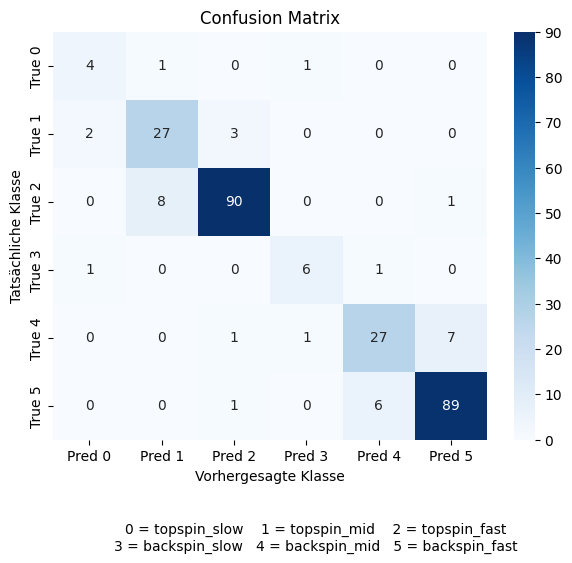

In [47]:
preds = [p for p,l in predictions]
labels = [l for p,l in predictions]

cm = confusion_matrix(labels, preds, labels=list(range(6)))
print("Confusion Matrix:")
print(cm)

# Schöne Visualisierung
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=[f"Pred {i}" for i in range(6)],
            yticklabels=[f"True {i}" for i in range(6)])
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.title("Confusion Matrix")

plt.subplots_adjust(bottom=0.2)  # extra Platz unten

# Beschreibung der Klassen unterhalb einfügen
label_text = (
    "0 = topspin_slow    1 = topspin_mid    2 = topspin_fast\n"
    "3 = backspin_slow   4 = backspin_mid   5 = backspin_fast"
)
plt.figtext(0.5, 0.02, label_text, 
            wrap=True, horizontalalignment='center', fontsize=10)

plt.show()